<h1>Curva de aprendizaje</h1>

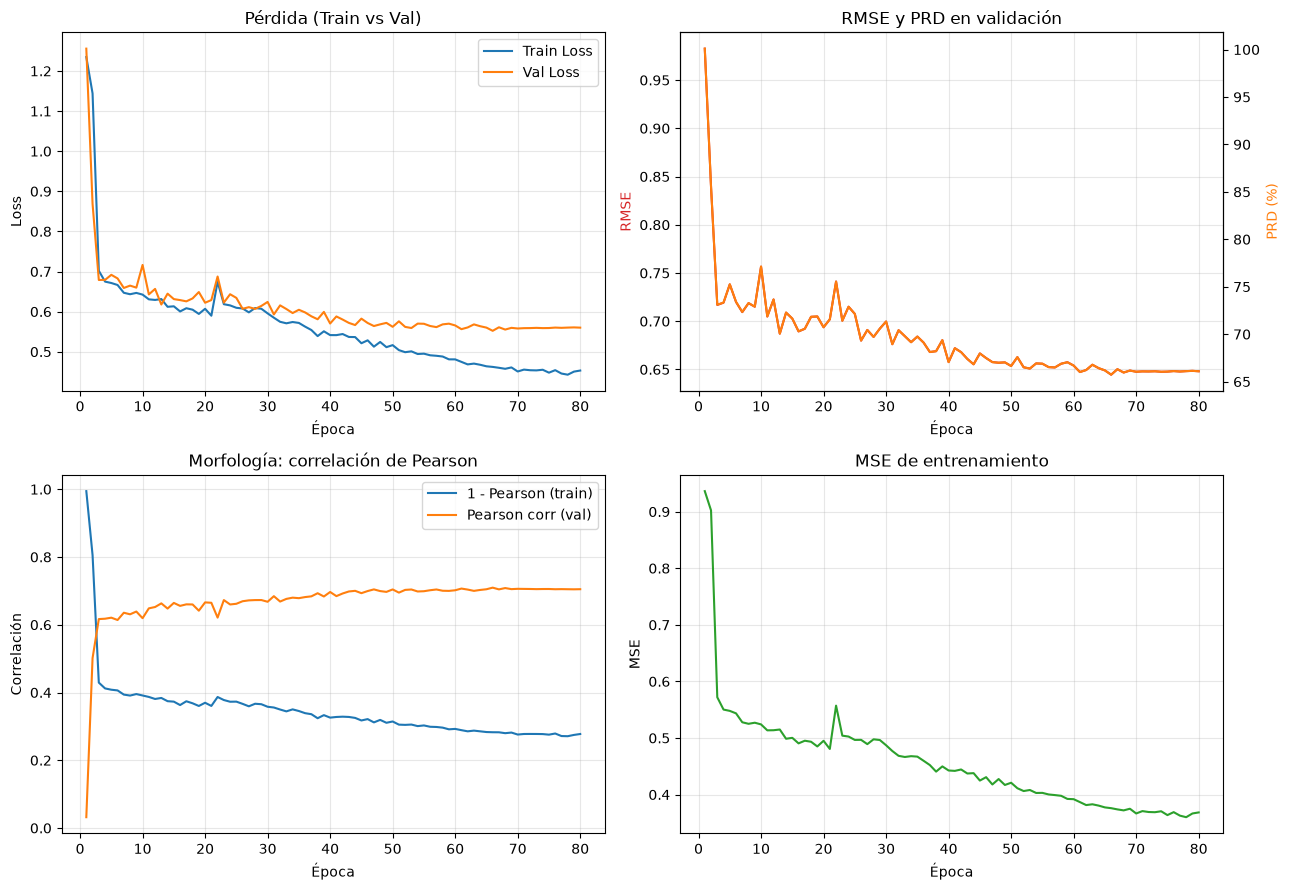

Mejor época: 66
  Val Loss = 0.5522
  Val RMSE = 0.6446
  Val PRD  = 65.73%
  Val Corr = 0.7095


In [7]:
import json
# %pip install matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

HISTORY_PATH = Path("checkpoints/history.json")

def load_history(path=HISTORY_PATH):
    if not path.exists():
        raise FileNotFoundError(
            f"No se encontró {path}. ¿Ya corriste al menos 1 época de entrenamiento?"
        )
    with open(path) as f:
        return json.load(f)

def plot_learning_curves(history):
    epochs = [h["epoch"] for h in history]
    train_loss = [h["train"]["loss"] for h in history]
    val_loss   = [h["val"]["loss"] for h in history]
    train_mse  = [h["train"]["mse"] for h in history]
    val_rmse   = [h["val"].get("rmse_mean") for h in history]
    val_prd    = [h["val"].get("prd_mean") for h in history]
    val_corr   = [h["val"].get("corr_mean") for h in history]
    train_pear = [h["train"]["pearson"] for h in history]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    ax = axes[0, 0]
    ax.plot(epochs, train_loss, label="Train Loss")
    ax.plot(epochs, val_loss, label="Val Loss")
    ax.set_xlabel("Época"); ax.set_ylabel("Loss")
    ax.set_title("Pérdida (Train vs Val)")
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[0, 1]
    ax.plot(epochs, val_rmse, label="RMSE (val)", color="tab:red")
    ax2 = ax.twinx()
    ax2.plot(epochs, val_prd, label="PRD % (val)", color="tab:orange")
    ax.set_xlabel("Época"); ax.set_ylabel("RMSE", color="tab:red")
    ax2.set_ylabel("PRD (%)", color="tab:orange")
    ax.set_title("RMSE y PRD en validación")
    ax.grid(alpha=0.3)

    ax = axes[1, 0]
    ax.plot(epochs, train_pear, label="1 - Pearson (train)")
    ax.plot(epochs, val_corr, label="Pearson corr (val)")
    ax.set_xlabel("Época"); ax.set_ylabel("Correlación")
    ax.set_title("Morfología: correlación de Pearson")
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1, 1]
    ax.plot(epochs, train_mse, label="Train MSE", color="tab:green")
    ax.set_xlabel("Época"); ax.set_ylabel("MSE")
    ax.set_title("MSE de entrenamiento")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("checkpoints/learning_curves.png", dpi=150)
    plt.show()

    best_idx = min(range(len(val_loss)), key=lambda i: val_loss[i])
    print(f"Mejor época: {epochs[best_idx]}")
    print(f"  Val Loss = {val_loss[best_idx]:.4f}")
    print(f"  Val RMSE = {val_rmse[best_idx]:.4f}")
    print(f"  Val PRD  = {val_prd[best_idx]:.2f}%")
    print(f"  Val Corr = {val_corr[best_idx]:.4f}")

if __name__ == "__main__":
    history = load_history()
    plot_learning_curves(history)